# Test completo di archivio, analisi e visualizzazione Sudoku

Questo notebook verifica l'intero flusso:

1. genera un nuovo Sudoku con soluzione unica;
2. lo salva nell'archivio;
3. lo ricarica dal file;
4. esegue l'analisi completa, che al primo accesso deve essere calcolata e salvata;
5. visualizza il risultato in tutti i modi disponibili;
6. richiede nuovamente la stessa analisi e verifica che venga restituita dalla cache in memoria.

Il notebook presuppone questi moduli nello stesso progetto:

- `sudoku_solver.py`
- `sudoku_archive.py`
- `sudoku_visualization.py`


In [5]:
import random
import time
import numpy as np

import matplotlib.pyplot as plt
import pandas as pd

import sudoku_solver as ss
import sudoku_archive as sa
import sudoku_visualization as sv
import sudoku_generator as sg

plt.rcParams["figure.figsize"] = (7, 7)
i = 0


In [ ]:
sudoku_ref_list = sa.list_sudokus()
sudoku_list = [sa.load_sudoku(x['name']) for x in sudoku_ref_list]
sudoku_analysis_list = []

for i, dummy in enumerate(sudoku_list):
    sudoku_analysis_list.append(sa.analyse_puzzle_cached(dummy['grid'], dummy['name']))
    if i % 10:
        print(f"analizzati {i} sudoku, {len(sudoku_list) - i} rimanenti...")
    i+= 1

analizzati 1 sudoku, 130 rimanenti...
analizzati 2 sudoku, 129 rimanenti...
analizzati 3 sudoku, 128 rimanenti...
analizzati 4 sudoku, 127 rimanenti...
analizzati 5 sudoku, 126 rimanenti...
analizzati 6 sudoku, 125 rimanenti...
analizzati 7 sudoku, 124 rimanenti...
analizzati 8 sudoku, 123 rimanenti...
analizzati 9 sudoku, 122 rimanenti...
analizzati 11 sudoku, 120 rimanenti...
analizzati 12 sudoku, 119 rimanenti...
analizzati 13 sudoku, 118 rimanenti...
analizzati 14 sudoku, 117 rimanenti...
analizzati 15 sudoku, 116 rimanenti...
analizzati 16 sudoku, 115 rimanenti...
analizzati 17 sudoku, 114 rimanenti...
analizzati 18 sudoku, 113 rimanenti...
analizzati 19 sudoku, 112 rimanenti...
analizzati 21 sudoku, 110 rimanenti...
analizzati 22 sudoku, 109 rimanenti...
analizzati 23 sudoku, 108 rimanenti...
analizzati 24 sudoku, 107 rimanenti...
analizzati 25 sudoku, 106 rimanenti...
analizzati 26 sudoku, 105 rimanenti...
analizzati 27 sudoku, 104 rimanenti...
analizzati 28 sudoku, 103 rimanent

## 3. Caricamento del Sudoku

Il Sudoku viene ricaricato usando il nome assegnato. La griglia caricata viene confrontata con quella generata.


In [ ]:
#loaded_info = sa.load_sudoku('coach_dev_1')
loaded_info = sudoku_list[i]
loaded_puzzle = loaded_info["grid"]
first_result = sudoku_analysis_list[i]

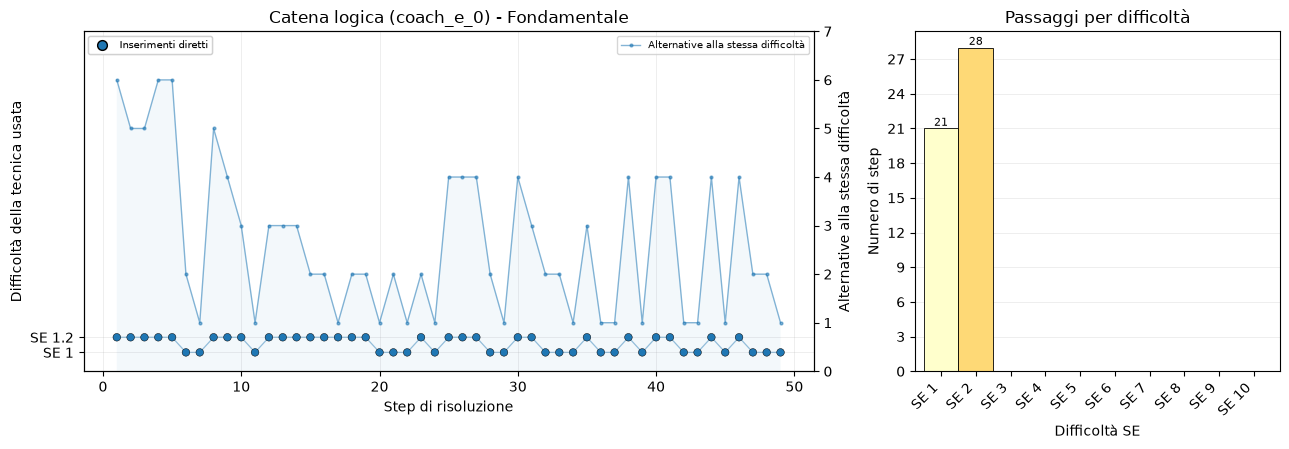

(<Figure size 1300x460 with 3 Axes>,
 (<Axes: title={'center': 'Catena logica (coach_e_0) - Fondamentale'}, xlabel='Step di risoluzione', ylabel='Difficoltà della tecnica usata'>,
  <Axes: title={'center': 'Passaggi per difficoltà'}, xlabel='Difficoltà SE', ylabel='Numero di step'>,
  <Axes: ylabel='Alternative alla stessa difficoltà'>))

In [ ]:
sv.plot_difficulty_chain(first_result)

Sudoku caricato
ID: e1e2d08ceb03386ebf4c
Nome: coach_e_0
Percorso: sudoku_data\puzzles\e1e2d08ceb03386ebf4c.json


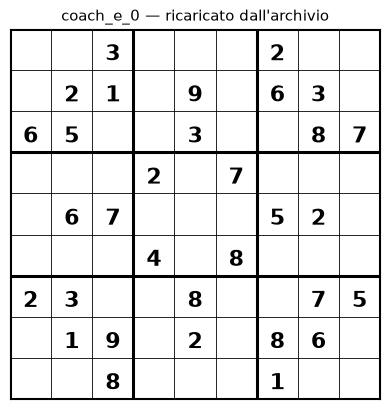

In [ ]:
print("Sudoku caricato")
print("ID:", loaded_info["id"])
print("Nome:", loaded_info["name"])
print("Percorso:", loaded_info["path"])

sv.draw_grid(
    loaded_puzzle,
    title=f"{loaded_info['name']} — ricaricato dall'archivio",
)
plt.show()


In [ ]:
if hasattr(sv, "plot_technique_activity"):
    has_activity_data = any(
        "applicable_by_technique" in step
        for step in first_result["chain"]
    )

    if has_activity_data:
        sv.plot_technique_activity(first_result)
    else:
        print(
            "La funzione esiste, ma l'analisi non contiene "
            "'applicable_by_technique'. Aggiorna solve_and_log "
            "e incrementa ANALYSIS_VERSION."
        )
else:
    print(
        "plot_technique_activity non è presente in "
        "sudoku_visualization.py."
    )


Catena vuota o nessuna attività disponibile da visualizzare.
